In [3]:
import os 
import sys 

sys.path.append(os.path.abspath("../"))

In [13]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from src.algorithms import linear_regression
from src.eval.metrics import Metrics
import mlflow

In [14]:
from src.utils import utils

In [15]:
data = pd.read_csv("data/data_for_lr.csv")
data = data.dropna()
data = data.apply(pd.to_numeric, errors='coerce')

In [ ]:
mlflow.create_experiment(name="exp_1",
                         artifact_location="/home/nilesh/projects/")

'451150763571642532'

In [7]:
mlflow.set_experiment("exp_1")

2025/08/09 19:06:59 INFO mlflow.tracking.fluent: Experiment with name 'exp_1' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///home/nilesh/projects/house_price_prediction/notebooks/mlruns/187050418118518883', creation_time=1754766419540, experiment_id='187050418118518883', last_update_time=1754766419540, lifecycle_stage='active', name='exp_1', tags={}>

In [17]:
data.columns
X = np.array(data.drop("y", axis=1))
y = np.array(data['y'])

X_train, X_test, y_train, y_test = utils.train_test_split(X,y)

In [15]:
with mlflow.start_run() as run:
    lr = linear_regression.LinearRegression()
    mlflow.log_param("lr", 0.001)
    
    lr.fit(X_train,y_train)
    y_pred = lr.predict(X_test)
    run_id = run.info.run_id
    mlflow.sklearn.log_model(sk_model=lr, name = "lr_model",
                             input_example = X_train[:2],
                             registered_model_name = "HousePricePred")
    mlflow.log_metric("accuracy", Metrics.accuracy(y_test, y_pred))
    mlflow.log_metric("cost", lr.cost_function(y_pred, y_test))

2025/08/09 07:36:16 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'HousePricePred' already exists. Creating a new version of this model...
Created version '3' of model 'HousePricePred'.


In [13]:
y_pred = lr.predict(X_test)

In [15]:
lr.cost_function(y_pred, y_test)

np.float64(8.110140053741082)

In [16]:
X_train.shape

(525, 1)

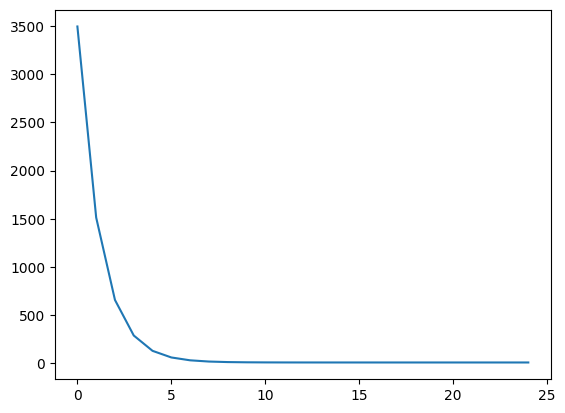

In [17]:
lr.plot_cost()

In [18]:
lr.save_model("../lr_model.pkl")

In [22]:
import pickle
with open("../lr_model.pkl", "rb") as f:
    model = pickle.load(f)

model.predict(X_test)

array([[4.89868736e+01],
       [6.99759887e+01],
       [8.09702870e+01],
       [3.49941303e+01],
       [2.59987953e+01],
       [7.59728787e+01],
       [4.99863553e+01],
       [5.59832453e+01],
       [1.22719387e-02],
       [5.09858370e+01],
       [5.09858370e+01],
       [2.20008686e+01],
       [5.49837637e+01],
       [7.89713237e+01],
       [3.01071694e+00],
       [4.19905020e+01],
       [8.29692503e+01],
       [1.10065703e+01],
       [7.00864361e+00],
       [6.99759887e+01],
       [8.29692503e+01],
       [5.00968028e+00],
       [1.00070886e+01],
       [3.01071694e+00],
       [3.09962036e+01],
       [7.39739153e+01],
       [7.79718420e+01],
       [2.49993136e+01],
       [8.39687320e+01],
       [4.19905020e+01],
       [6.69775437e+01],
       [1.22719387e-02],
       [4.29899836e+01],
       [9.00760695e+00],
       [8.39687320e+01],
       [4.89868736e+01],
       [2.10013870e+01],
       [5.79822087e+01],
       [9.00760695e+00],
       [9.49630304e+01],


In [1]:
import mlflow

In [2]:
from src.pipelines import train

In [3]:
from src.utils.utils import Config, timeit
conf = Config("config/config.yml").load_config()

In [4]:
train_pipe = train.TrainPipeline(conf)

In [ ]:
run_id, model_id = train_pipe.execute()

Loaded data with 700 rows
[Timing] Function 'load_and_preprocess_data' executed in 0.255 seconds
[Timing] Function 'initialize_model' executed in 0.000 seconds


2025/08/09 19:25:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/08/09 19:25:52 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[Timing] Function 'train_and_evaluate_model' executed in 9.739 seconds
[Timing] Function 'execute' executed in 10.113 seconds


Registered model 'HousePricePred' already exists. Creating a new version of this model...
Created version '12' of model 'HousePricePred'.


In [9]:
model_data.model_id

'm-bc28d34f1e954f788941254bebe1ac94'

In [6]:
import mlflow
model = mlflow.sklearn.load_model(f"runs:/{run_id}/lr_model")

In [12]:
artifact_path= "lr_model"
local_model_path = mlflow.artifacts.download_artifacts(artifact_uri=f"runs:/{run_id}/{artifact_path}")


In [13]:
local_model_path

'/tmp/tmpp1lxf7sv/lr_model/'

In [11]:
import pickle
with open(f"/home/nilesh/projects/models/{model_data.model_id}/artifacts/model.pkl", "rb") as f:
    model = pickle.load(f)

In [18]:
model.predict(X_test)

array([[89.93593277],
       [90.93505602],
       [57.96398892],
       [29.98853804],
       [16.0008126 ],
       [16.99993585],
       [16.0008126 ],
       [80.94382356],
       [ 2.01308716],
       [25.99204506],
       [ 3.01221041],
       [75.94820734],
       [54.96661918],
       [90.93505602],
       [70.95259111],
       [97.92891874],
       [97.92891874],
       [ 4.01133366],
       [98.92804198],
       [88.93680953],
       [57.96398892],
       [51.96924944],
       [57.96398892],
       [37.981524  ],
       [66.95609813],
       [94.931549  ],
       [55.96574242],
       [21.99555208],
       [93.93242576],
       [51.96924944],
       [ 5.0104569 ],
       [11.00519637],
       [41.97801699],
       [42.97714023],
       [57.96398892],
       [29.98853804],
       [76.94733058],
       [46.97363321],
       [ 7.00870339],
       [81.94294681],
       [67.95522137],
       [34.98415427],
       [46.97363321],
       [ 3.01221041],
       [80.94382356],
       [16